# Multi-Regressor Pipeline (Direct Load Train/Val/Test)
Notebook ini mencakup:
1. Load data train/validation/test dari file CSV yang sudah tersedia
2. Siapkan fitur dan target multi-output tanpa split ulang
3. Standardisasi fitur dan target
4. Simpan split (raw + scaled), scaler, metadata scaler
5. Training MultiOutput Regressor + evaluasi

In [1]:
from pathlib import Path
from time import perf_counter
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

In [7]:
# Konfigurasi path
step_start = perf_counter()

INPUT_DIR = Path('.')
TRAIN_PATH = INPUT_DIR / 'preprocessing_outputs_aug_v2/java_ash_train_augmented_encoded.csv'
VAL_PATH = INPUT_DIR / 'preprocessing_outputs_aug_v2/java_ash_val_encoded.csv'
TEST_PATH = INPUT_DIR / 'preprocessing_outputs_aug_v2/java_ash_test_encoded.csv'

ARTIFACT_DIR = Path('artifacts_multi_regressor_aug_v2')
SPLIT_DIR = ARTIFACT_DIR / 'splits'
SCALER_DIR = ARTIFACT_DIR / 'scalers'
MODEL_DIR = ARTIFACT_DIR / 'model'
METRIC_DIR = ARTIFACT_DIR / 'metrics'

for d in [ARTIFACT_DIR, SPLIT_DIR, SCALER_DIR, MODEL_DIR, METRIC_DIR]:
    d.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
process_times = {}

process_times['setup_paths'] = perf_counter() - step_start
print(f"Waktu setup_paths: {process_times['setup_paths']:.6f} detik")
print('Input files:')
print('-', TRAIN_PATH)
print('-', VAL_PATH)
print('-', TEST_PATH)
print('Artifact dir versi baru:', ARTIFACT_DIR)

Waktu setup_paths: 0.001505 detik
Input files:
- preprocessing_outputs_aug_v2\java_ash_train_augmented_encoded.csv
- preprocessing_outputs_aug_v2\java_ash_val_encoded.csv
- preprocessing_outputs_aug_v2\java_ash_test_encoded.csv
Artifact dir versi baru: artifacts_multi_regressor_aug_v2


In [8]:
# Load data train/val/test dari file terpisah
step_start = perf_counter()

for p in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    if not p.exists():
        raise FileNotFoundError(f'File tidak ditemukan: {p}')

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

process_times['load_data'] = perf_counter() - step_start
print(f"Waktu load_data: {process_times['load_data']:.6f} detik")
print('Shape train:', train_df.shape)
print('Shape val  :', val_df.shape)
print('Shape test :', test_df.shape)
train_df.head()

Waktu load_data: 0.035611 detik
Shape train: (8000, 19)
Shape val  : (341, 19)
Shape test : (342, 19)


,id,timestamp,alert_level,latitude,longitude,elevation,tinggi_letusan_m,kec_angin_km_jam,arah_angin_deg,amplitudo,duration,jarak_km,luas_km2,sudut_deg,radius_km,volcano_filter_Bromo,volcano_filter_Merapi,volcano_filter_Raung,volcano_filter_Semeru
0,1652,2,1,-8.123735,114.039080,3332,1278.657175,7.045481,231.395353,12.621366,121.878782,34.494420,0.000000,309.171766,9.513491,0,0,1,0
1,1667,6,1,-8.123314,114.038575,3332,19724.534182,7.991023,129.588183,5.237928,119.207849,50.535607,185.610679,350.568295,25.311322,0,0,1,0
2,1551,7,1,-8.105096,112.918359,3676,596.955913,0.695739,193.864938,22.417334,27.752157,12.836212,479.763599,6.915086,4.513697,0,0,0,1
3,1693,1,3,-8.124275,114.040547,3332,20856.325769,12.042612,85.595558,13.915070,126.255824,27.142432,350.362405,252.424605,21.819699,0,0,1,0
4,1632,4,1,-7.941559,112.951928,2329,8656.536600,6.967262,136.540679,8.980861,124.002421,85.911765,817.289461,218.915146,22.362665,1,0,0,0


In [9]:
# Pilih target multi-output (sesuaikan jika ingin target lain)
step_start = perf_counter()

target_cols = ['jarak_km', 'luas_km2', 'sudut_deg', 'radius_km']
optional_drop_cols = ['id']

def validate_targets(df, split_name, targets):
    missing_targets = [c for c in targets if c not in df.columns]
    if missing_targets:
        raise ValueError(
            f'Target tidak ditemukan di {split_name}: {missing_targets}'
        )

validate_targets(train_df, 'train_df', target_cols)
validate_targets(val_df, 'val_df', target_cols)
validate_targets(test_df, 'test_df', target_cols)

drop_cols = target_cols + [c for c in optional_drop_cols if c in train_df.columns]
feature_cols = [c for c in train_df.columns if c not in drop_cols]

missing_feature_cols_val = [c for c in feature_cols if c not in val_df.columns]
missing_feature_cols_test = [c for c in feature_cols if c not in test_df.columns]
if missing_feature_cols_val or missing_feature_cols_test:
    raise ValueError(
        'Kolom fitur train/val/test tidak konsisten. '
        f'Missing di val: {missing_feature_cols_val}; '
        f'Missing di test: {missing_feature_cols_test}'
    )

process_times['prepare_features_targets'] = perf_counter() - step_start
print(f"Waktu prepare_features_targets: {process_times['prepare_features_targets']:.6f} detik")
print('Kolom yang di-drop dari fitur:', [c for c in optional_drop_cols if c in train_df.columns])
print('Jumlah fitur:', len(feature_cols))
print('Fitur:', feature_cols)
print('Target:', target_cols)

Waktu prepare_features_targets: 0.000674 detik
Kolom yang di-drop dari fitur: ['id']
Jumlah fitur: 14
Fitur: ['timestamp', 'alert_level', 'latitude', 'longitude', 'elevation', 'tinggi_letusan_m', 'kec_angin_km_jam', 'arah_angin_deg', 'amplitudo', 'duration', 'volcano_filter_Bromo', 'volcano_filter_Merapi', 'volcano_filter_Raung', 'volcano_filter_Semeru']
Target: ['jarak_km', 'luas_km2', 'sudut_deg', 'radius_km']


In [10]:
# Siapkan X/y langsung dari data split yang sudah ada (tanpa split ulang)
step_start = perf_counter()

X_train = train_df[feature_cols].copy()
X_val = val_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()

y_train = train_df[target_cols].copy()
y_val = val_df[target_cols].copy()
y_test = test_df[target_cols].copy()

process_times['prepare_split_data'] = perf_counter() - step_start
print(f"Waktu prepare_split_data: {process_times['prepare_split_data']:.6f} detik")
print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape}, y_val:   {y_val.shape}')
print(f'X_test:  {X_test.shape}, y_test:  {y_test.shape}')

Waktu prepare_split_data: 0.004547 detik
X_train: (8000, 14), y_train: (8000, 4)
X_val:   (341, 14), y_val:   (341, 4)
X_test:  (342, 14), y_test:  (342, 4)


In [11]:
# Standardisasi (fit hanya di data train)
step_start = perf_counter()

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = pd.DataFrame(x_scaler.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_val_scaled = pd.DataFrame(x_scaler.transform(X_val), columns=feature_cols, index=X_val.index)
X_test_scaled = pd.DataFrame(x_scaler.transform(X_test), columns=feature_cols, index=X_test.index)

y_train_scaled = pd.DataFrame(y_scaler.fit_transform(y_train), columns=target_cols, index=y_train.index)
y_val_scaled = pd.DataFrame(y_scaler.transform(y_val), columns=target_cols, index=y_val.index)
y_test_scaled = pd.DataFrame(y_scaler.transform(y_test), columns=target_cols, index=y_test.index)

process_times['standardize_data'] = perf_counter() - step_start
print(f"Waktu standardize_data: {process_times['standardize_data']:.6f} detik")
print('Standardisasi selesai.')

Waktu standardize_data: 0.014624 detik
Standardisasi selesai.


In [12]:
# Simpan data split mentah
step_start = perf_counter()

X_train.to_csv(SPLIT_DIR / 'X_train_raw.csv', index=False)
X_val.to_csv(SPLIT_DIR / 'X_val_raw.csv', index=False)
X_test.to_csv(SPLIT_DIR / 'X_test_raw.csv', index=False)
y_train.to_csv(SPLIT_DIR / 'y_train_raw.csv', index=False)
y_val.to_csv(SPLIT_DIR / 'y_val_raw.csv', index=False)
y_test.to_csv(SPLIT_DIR / 'y_test_raw.csv', index=False)

# Simpan data split hasil standardisasi
X_train_scaled.to_csv(SPLIT_DIR / 'X_train_scaled.csv', index=False)
X_val_scaled.to_csv(SPLIT_DIR / 'X_val_scaled.csv', index=False)
X_test_scaled.to_csv(SPLIT_DIR / 'X_test_scaled.csv', index=False)
y_train_scaled.to_csv(SPLIT_DIR / 'y_train_scaled.csv', index=False)
y_val_scaled.to_csv(SPLIT_DIR / 'y_val_scaled.csv', index=False)
y_test_scaled.to_csv(SPLIT_DIR / 'y_test_scaled.csv', index=False)

process_times['save_splits'] = perf_counter() - step_start
print(f"Waktu save_splits: {process_times['save_splits']:.6f} detik")
print('Semua split data berhasil disimpan di folder splits.')

Waktu save_splits: 0.298838 detik
Semua split data berhasil disimpan di folder splits.


In [13]:
# Simpan scaler (format PKL)
step_start = perf_counter()

with open(SCALER_DIR / 'x_scaler.pkl', 'wb') as f:
    pickle.dump(x_scaler, f)

with open(SCALER_DIR / 'y_scaler.pkl', 'wb') as f:
    pickle.dump(y_scaler, f)

# Simpan metadata scaler
x_scaler_metadata = {
    'feature_names': feature_cols,
    'mean': x_scaler.mean_.tolist(),
    'scale': x_scaler.scale_.tolist(),
    'var': x_scaler.var_.tolist(),
    'n_features_in': int(x_scaler.n_features_in_),
}

y_scaler_metadata = {
    'target_names': target_cols,
    'mean': y_scaler.mean_.tolist(),
    'scale': y_scaler.scale_.tolist(),
    'var': y_scaler.var_.tolist(),
    'n_features_in': int(y_scaler.n_features_in_),
}

with open(SCALER_DIR / 'x_scaler_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(x_scaler_metadata, f, indent=2)

with open(SCALER_DIR / 'y_scaler_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(y_scaler_metadata, f, indent=2)

process_times['save_scalers_and_metadata'] = perf_counter() - step_start
print(f"Waktu save_scalers_and_metadata: {process_times['save_scalers_and_metadata']:.6f} detik")
print('Scaler PKL dan metadata scaler berhasil disimpan.')

Waktu save_scalers_and_metadata: 0.004808 detik
Scaler PKL dan metadata scaler berhasil disimpan.


In [14]:
# Training multi-regressor XGBoost pada data yang sudah distandardisasi
step_start = perf_counter()

xgb_params = {
    'n_estimators': 300,
    'learning_rate': 0.05,
    'max_depth': 5,
    'min_child_weight': 1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.0,
    'reg_lambda': 1.0,
    'objective': 'reg:squarederror',
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
}

base_model = XGBRegressor(**xgb_params)
model = MultiOutputRegressor(base_model)
model.fit(X_train_scaled, y_train_scaled)

with open(MODEL_DIR / 'multi_output_xgboost.pkl', 'wb') as f:
    pickle.dump(model, f)

with open(MODEL_DIR / 'xgboost_hyperparameters.json', 'w', encoding='utf-8') as f:
    json.dump(xgb_params, f, indent=2)

process_times['train_model'] = perf_counter() - step_start
print(f"Waktu train_model: {process_times['train_model']:.6f} detik")
print('Model XGBoost berhasil dilatih dan disimpan.')
print('Hyperparameter XGBoost:', xgb_params)

Waktu train_model: 2.227876 detik
Model XGBoost berhasil dilatih dan disimpan.
Hyperparameter XGBoost: {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.0, 'reg_lambda': 1.0, 'objective': 'reg:squarederror', 'random_state': 42, 'n_jobs': -1}


In [15]:
# Evaluasi di validation dan test (dikembalikan ke skala asli target)
step_start = perf_counter()

def evaluate_split(split_name, X_split_scaled, y_split_raw):
    y_pred_scaled = model.predict(X_split_scaled)
    y_pred_raw = y_scaler.inverse_transform(y_pred_scaled)

    rows = []
    for i, target in enumerate(target_cols):
        y_true = y_split_raw[target].values
        y_pred = y_pred_raw[:, i]

        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)

        rows.append({
            'split': split_name,
            'target': target,
            'MAE': float(mae),
            'RMSE': float(rmse),
            'R2': float(r2),
        })

    return pd.DataFrame(rows)

val_metrics = evaluate_split('val', X_val_scaled, y_val)
test_metrics = evaluate_split('test', X_test_scaled, y_test)
metrics_df = pd.concat([val_metrics, test_metrics], ignore_index=True)

metrics_df.to_csv(METRIC_DIR / 'metrics_per_target.csv', index=False)

summary = metrics_df.groupby('split')[['MAE', 'RMSE', 'R2']].mean().reset_index()
summary.to_csv(METRIC_DIR / 'metrics_summary.csv', index=False)

process_times['evaluate_and_save_metrics'] = perf_counter() - step_start
print(f"Waktu evaluate_and_save_metrics: {process_times['evaluate_and_save_metrics']:.6f} detik")
print('Metrik tersimpan di folder metrics.')
display(metrics_df)
display(summary)

Waktu evaluate_and_save_metrics: 0.082750 detik
Metrik tersimpan di folder metrics.


,split,target,MAE,RMSE,R2
0,val,jarak_km,8.774052,18.322905,0.443074
1,val,luas_km2,219.920915,417.581959,0.300469
2,val,sudut_deg,58.195716,76.722155,0.508672
3,val,radius_km,4.528998,9.287052,0.523822
4,test,jarak_km,7.601399,14.947917,0.574087
5,test,luas_km2,226.386734,509.956227,0.141081
6,test,sudut_deg,55.704943,73.591576,0.536603
7,test,radius_km,4.604779,9.862522,0.439534


,split,MAE,RMSE,R2
0,test,73.574464,152.089560,0.422826
1,val,72.854920,130.478518,0.444009


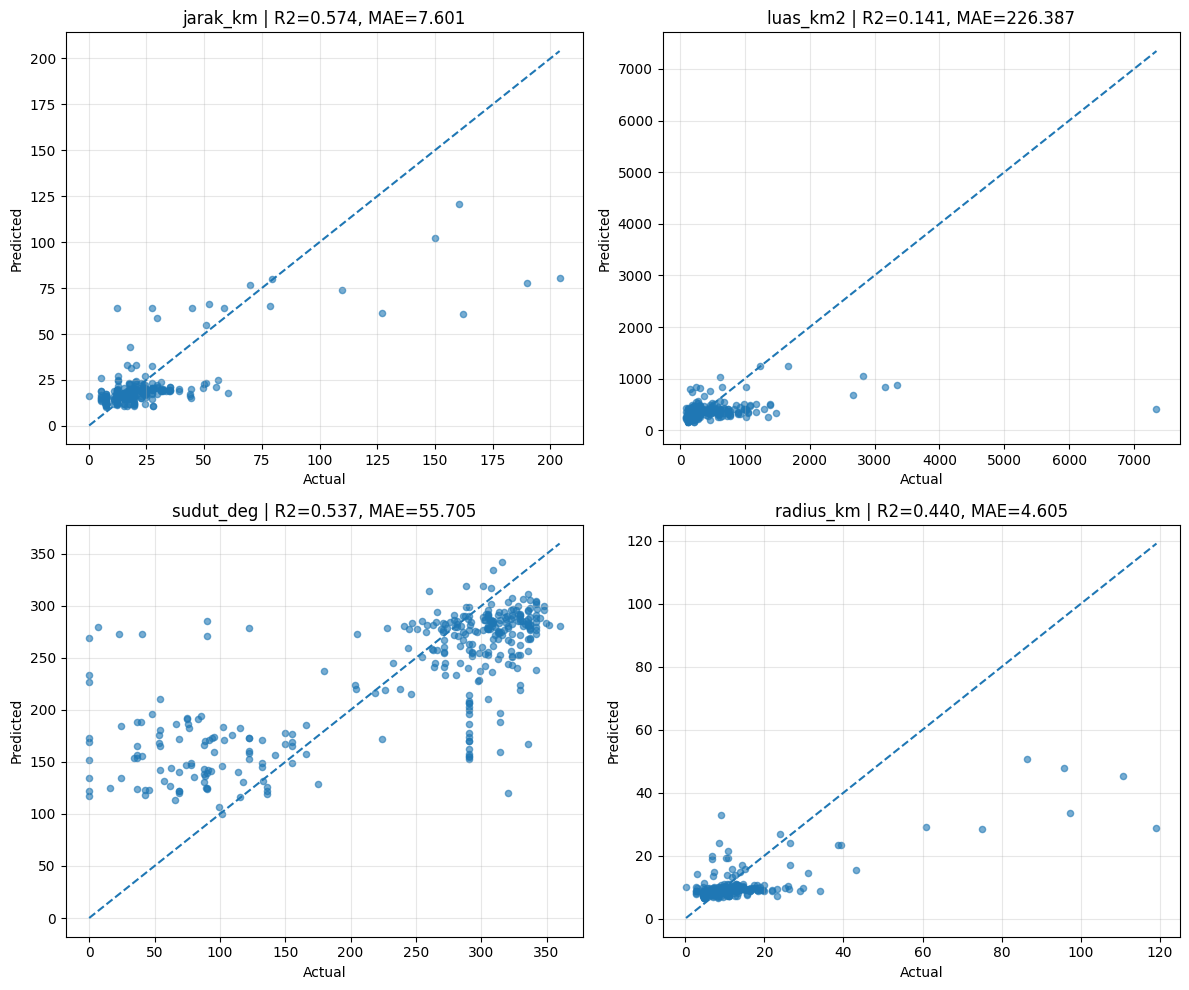

Waktu plot_test_regression: 1.094611 detik
Plot regresi test disimpan ke: artifacts_multi_regressor_aug_v2\metrics\test_regression_plots.png


In [16]:
# Plot regresi hasil prediksi pada data test
step_start = perf_counter()

y_test_pred_scaled = model.predict(X_test_scaled)
y_test_pred_raw = y_scaler.inverse_transform(y_test_pred_scaled)

n_targets = len(target_cols)
n_cols = 2
n_rows = (n_targets + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))
axes = np.array(axes).reshape(-1)

for i, target in enumerate(target_cols):
    ax = axes[i]
    y_true = y_test[target].values
    y_pred = y_test_pred_raw[:, i]

    ax.scatter(y_true, y_pred, alpha=0.6, s=20)
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], linestyle='--', linewidth=1.5)

    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    ax.set_title(f'{target} | R2={r2:.3f}, MAE={mae:.3f}')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.grid(alpha=0.3)

for j in range(n_targets, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plot_path = METRIC_DIR / 'test_regression_plots.png'
fig.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)

process_times['plot_test_regression'] = perf_counter() - step_start
print(f"Waktu plot_test_regression: {process_times['plot_test_regression']:.6f} detik")
print('Plot regresi test disimpan ke:', plot_path)

In [17]:
# Ringkasan file artefak yang tersimpan
step_start = perf_counter()

saved_files = sorted([str(p) for p in ARTIFACT_DIR.rglob('*') if p.is_file()])
print('Daftar file artefak:')
for f in saved_files:
    print('-', f)

process_times['list_artifacts'] = perf_counter() - step_start
print(f"Waktu list_artifacts: {process_times['list_artifacts']:.6f} detik")

# Simpan dan tampilkan rekap waktu proses
timing_df = pd.DataFrame(
    [{'process': k, 'duration_seconds': v} for k, v in process_times.items()]
 ).sort_values('duration_seconds', ascending=False).reset_index(drop=True)

timing_df.to_csv(METRIC_DIR / 'process_times.csv', index=False)
print("Rekap waktu proses disimpan ke:", METRIC_DIR / 'process_times.csv')
display(timing_df)

Daftar file artefak:
- artifacts_multi_regressor_aug_v2\metrics\metrics_per_target.csv
- artifacts_multi_regressor_aug_v2\metrics\metrics_summary.csv
- artifacts_multi_regressor_aug_v2\metrics\test_regression_plots.png
- artifacts_multi_regressor_aug_v2\model\multi_output_xgboost.pkl
- artifacts_multi_regressor_aug_v2\model\xgboost_hyperparameters.json
- artifacts_multi_regressor_aug_v2\scalers\x_scaler.pkl
- artifacts_multi_regressor_aug_v2\scalers\x_scaler_metadata.json
- artifacts_multi_regressor_aug_v2\scalers\y_scaler.pkl
- artifacts_multi_regressor_aug_v2\scalers\y_scaler_metadata.json
- artifacts_multi_regressor_aug_v2\splits\X_test_raw.csv
- artifacts_multi_regressor_aug_v2\splits\X_test_scaled.csv
- artifacts_multi_regressor_aug_v2\splits\X_train_raw.csv
- artifacts_multi_regressor_aug_v2\splits\X_train_scaled.csv
- artifacts_multi_regressor_aug_v2\splits\X_val_raw.csv
- artifacts_multi_regressor_aug_v2\splits\X_val_scaled.csv
- artifacts_multi_regressor_aug_v2\splits\y_test_r

,process,duration_seconds
0,train_model,2.227876
1,plot_test_regression,1.094611
2,save_splits,0.298838
3,evaluate_and_save_metrics,0.082750
4,load_data,0.035611
5,standardize_data,0.014624
6,save_scalers_and_metadata,0.004808
7,prepare_split_data,0.004547
8,list_artifacts,0.003129
9,setup_paths,0.001505
